# Práctica 01: series de tiempo con Yahoo Finance

**Objetivo:** analizar el precio diario de Bitcoin (`BTC-USD`) y aplicar las fases de Box–Jenkins: identificación, estimación, diagnóstico y pronóstico.

Se sigue la lógica de los tres notebooks y los tres PDF de `TeoriayScrips`. Ejecutar las celdas en orden con el entorno **jupyterev**.

## 1. Librerías

Si se utiliza otro entorno, instalar primero: `%pip install yfinance pandas numpy matplotlib statsmodels`.

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from IPython.display import display
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tools.sm_exceptions import InterpolationWarning

plt.rcParams['figure.figsize'] = (10, 4)
alpha = 0.05

## 2. Llamado al dataset

Fuente: [Bitcoin en Yahoo Finance](https://finance.yahoo.com/quote/BTC-USD/history/). Se utilizan los cierres diarios de 2020 a 2025; `end` es exclusivo.

Los datos se cargan directamente desde Yahoo y se trabajan en memoria dentro del notebook. Esta celda requiere conexión a internet.

In [2]:
simbolo = 'BTC-USD'  # Cambia por 'AAPL', '^GSPC' o 'ETH-USD'
inicio, fin = '2020-01-01', '2026-01-01'
data = yf.Ticker(simbolo).history(start=inicio, end=fin, interval='1d', auto_adjust=False, actions=False)
if data.empty: raise ValueError('Yahoo no devolvió datos. Revisa ticker o conexión.')
data.index = pd.to_datetime(data.index, utc=True).tz_convert(None)
data = data.sort_index()
serie = data['Close'].dropna().astype(float)
if len(serie) < 80: raise ValueError('Se necesitan al menos 80 observaciones.')
print(f'{simbolo}: {len(serie)} observaciones')

BTC-USD: 2192 observaciones


## 3. Dataset y preparación

`Open`, `High`, `Low` y `Close` son precios en USD; `Volume` es el volumen reportado. La variable del modelo será **Close**.

In [3]:
print('Dimensiones:', data.shape)
print('Periodo:', data.index.min().date(), 'a', data.index.max().date())
display(data.head())
display(data.tail())
data.info()

Dimensiones: (2192, 6)
Periodo: 2020-01-01 a 2025-12-31


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-01,7194.892090,7254.330566,7174.944336,7200.174316,7200.174316,18565664997
2020-01-02,7202.551270,7212.155273,6935.270020,6985.470215,6985.470215,20802083465
2020-01-03,6984.428711,7413.715332,6914.996094,7344.884277,7344.884277,28111481032
2020-01-04,7345.375488,7427.385742,7309.514160,7410.656738,7410.656738,18444271275
2020-01-05,7410.451660,7544.497070,7400.535645,7411.317383,7411.317383,19725074095


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2025-12-27,87301.429688,87874.781250,87182.976562,87802.156250,87802.156250,13741199310
2025-12-28,87799.343750,87986.890625,87394.953125,87835.835938,87835.835938,15156557929
2025-12-29,87835.789062,90299.156250,86717.914062,87138.140625,87138.140625,48411625849
2025-12-30,87134.351562,89297.937500,86735.546875,88430.132812,88430.132812,35586356225
2025-12-31,88429.585938,89080.289062,87130.562500,87508.828125,87508.828125,33830210616


<class 'pandas.DataFrame'>
DatetimeIndex: 2192 entries, 2020-01-01 to 2025-12-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2192 non-null   float64
 1   High       2192 non-null   float64
 2   Low        2192 non-null   float64
 3   Close      2192 non-null   float64
 4   Adj Close  2192 non-null   float64
 5   Volume     2192 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 119.9 KB


In [4]:
display(data.describe().T)
display(data.isna().sum().rename('Nulos').to_frame())
print('Fechas duplicadas:', data.index.duplicated().sum())

,count,mean,std,min,25%,50%,75%,max
Open,2192.0,4.716006e+04,3.141991e+04,5.002578e+03,2.208503e+04,3.974162e+04,6.446287e+04,1.247521e+05
High,2192.0,4.808666e+04,3.189897e+04,5.331834e+03,2.260634e+04,4.074582e+04,6.586242e+04,1.261981e+05
Low,2192.0,4.618417e+04,3.090276e+04,4.106981e+03,2.145656e+04,3.872622e+04,6.317450e+04,1.231960e+05
Close,2192.0,4.719485e+04,3.141989e+04,4.970788e+03,2.219608e+04,3.976067e+04,6.451609e+04,1.247525e+05
Adj Close,2192.0,4.719485e+04,3.141989e+04,4.970788e+03,2.219608e+04,3.976067e+04,6.451609e+04,1.247525e+05
Volume,2192.0,3.648228e+10,2.162696e+10,5.331173e+09,2.221117e+10,3.198345e+10,4.537994e+10,3.509679e+11


,Nulos
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


Fechas duplicadas: 0


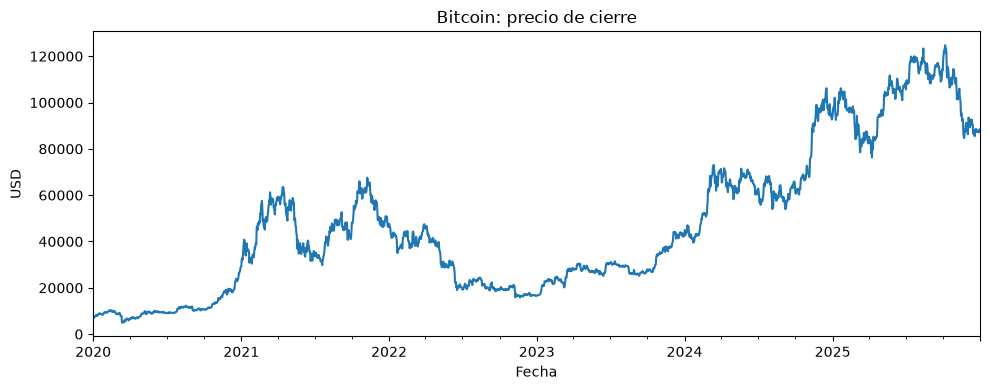

In [5]:
data = data.loc[~data.index.duplicated(keep='first')].copy()
serie = data['Close'].astype(float).asfreq('D')

if serie.isna().any():
    raise ValueError('Hay días sin precio. Revisar la descarga antes de modelar.')
if (serie <= 0).any():
    raise ValueError('Se encontraron precios no positivos.')

serie.plot(title='Bitcoin: precio de cierre', ylabel='USD', xlabel='Fecha')
plt.tight_layout()
plt.show()

## 4. Fase 1: identificación y estacionariedad

### 4.1. División temporal

El primer 80 % se utiliza para identificar y ajustar el modelo. El último 20 % se reserva para evaluar el pronóstico. Las pruebas y la elección de parámetros usan solamente `train`.

,Datos,Desde,Hasta
Entrenamiento,1753,2020-01-01,2024-10-18
Prueba,439,2024-10-19,2025-12-31


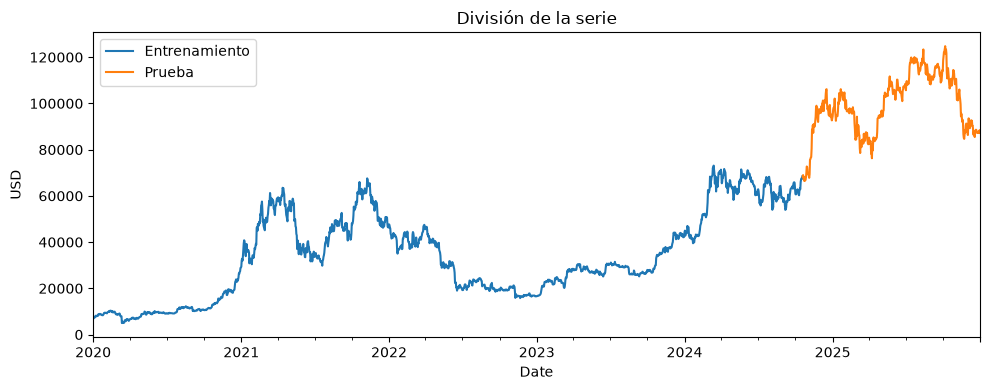

In [6]:
corte = int(len(serie) * 0.8)
train = serie.iloc[:corte]
test = serie.iloc[corte:]

display(pd.DataFrame({
    'Datos': [len(train), len(test)],
    'Desde': [train.index.min().date(), test.index.min().date()],
    'Hasta': [train.index.max().date(), test.index.max().date()]
}, index=['Entrenamiento', 'Prueba']))

train.plot(label='Entrenamiento')
test.plot(label='Prueba')
plt.title('División de la serie')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Estacionariedad

ADF: H₀ = la serie no es estacionaria; Hₐ = la serie es estacionaria. Si p-valor < 0,05 se rechaza H₀.

In [7]:
def prueba_adf(x, nombre):
    r = adfuller(x.dropna(), autolag='AIC', result_object=False)
    print(f'{nombre}: ADF={r[0]:.4f}; p-valor={r[1]:.4f};', 'estacionaria' if r[1] < alpha else 'no estacionaria')
    return r[1]
corte = int(len(serie) * 0.8)
train, test = serie.iloc[:corte], serie.iloc[corte:]
p0 = prueba_adf(train, 'Original')

Original: ADF=-1.1220; p-valor=0.7062; no estacionaria


### Diferenciación

Se revisan d=0, d=1 y d=2. Se usa el menor orden que pase ADF.

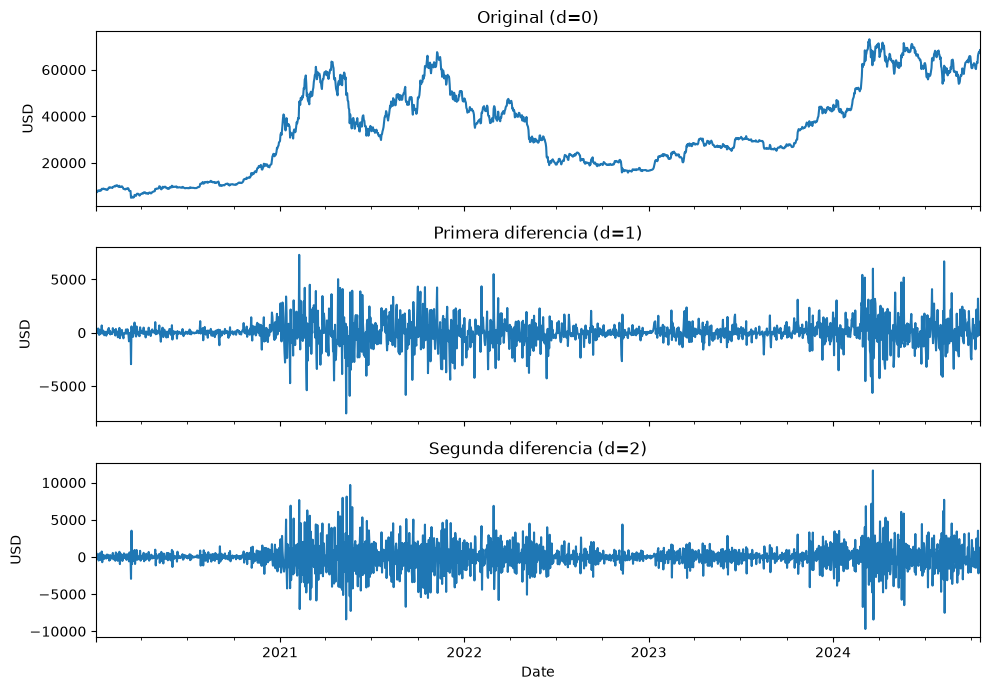

In [8]:
train_diff = train.diff().dropna()
train_diff2 = train_diff.diff().dropna()
series = [train, train_diff, train_diff2]
nombres = ['Original (d=0)', 'Primera diferencia (d=1)', 'Segunda diferencia (d=2)']

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for x, nombre, ax in zip(series, nombres, axes):
    x.plot(ax=ax, title=nombre)
    ax.set_ylabel('USD')
plt.tight_layout()
plt.show()

In [9]:
p1 = prueba_adf(train_diff, 'Primera diferencia')
p2 = prueba_adf(train_diff2, 'Segunda diferencia')
if p0 < alpha: d = 0
elif p1 < alpha: d = 1
elif p2 < alpha: d = 2
else: raise ValueError('No se logró estacionariedad con d=0, 1 o 2.')
serie_estacionaria = [train, train_diff, train_diff2][d]
print(f'Orden elegido: d={d}')
serie_estacionaria = [train, train_diff, train_diff2][d]


Primera diferencia: ADF=-43.9955; p-valor=0.0000; estacionaria
Segunda diferencia: ADF=-15.5883; p-valor=0.0000; estacionaria
Orden elegido: d=1


### 4.6. FAC y FACP para identificar p y q

| Modelo sobre la serie estacionaria | FAC | FACP |
|---|---|---|
| AR(p) | Decae gradualmente | Corte después de p |
| MA(q) | Corte después de q | Decae gradualmente |
| ARMA(p,q) | Decae gradualmente | Decae gradualmente |

Estos patrones son orientativos. Se comparan órdenes pequeños con AIC y BIC para apoyar la elección.

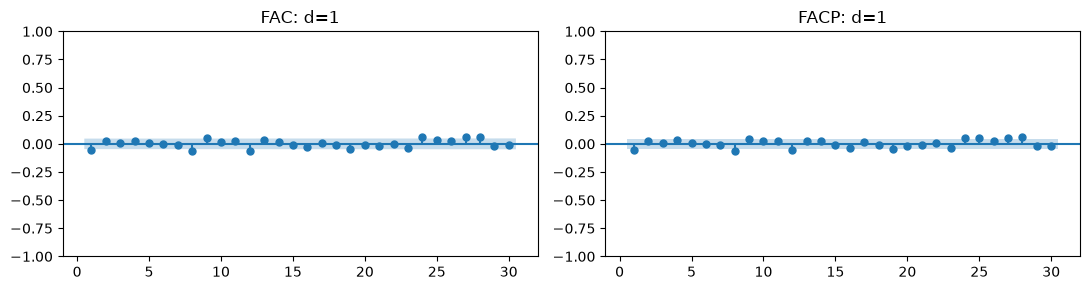

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
plot_acf(serie_estacionaria, lags=30, zero=False, ax=axes[0], title=f'FAC: d={d}')
plot_pacf(serie_estacionaria, lags=30, zero=False, method='ywm', ax=axes[1],
          title=f'FACP: d={d}')
plt.tight_layout()
plt.show()

## 5. Fase 2: estimación y comparación de modelos

Con `d=0`, ARIMA(p,0,0) es AR, ARIMA(0,0,q) es MA y ARIMA(p,0,q) es ARMA. Con `d>0`, el modelo de la serie original es **ARIMA(p,d,q)**, aunque las diferencias se modelen con AR, MA o ARMA.

Se prueban `p` y `q` entre 0 y 3. Se incluye ARIMA(0,1,0), un paseo aleatorio sin deriva, cuando `d=1`. Se ajusta **train original**: ARIMA realiza las diferencias internamente y devuelve pronósticos en USD. Se usa constante si `d=0` y sin tendencia determinista si `d>0`.

In [11]:
modelos, resultados = {}, []
trend = 'c' if d == 0 else 'n'
for p in range(3):
    for q in range(3):
        orden = (p, d, q)
        try:
            ajuste = ARIMA(train, order=orden, trend=trend).fit()
            if np.isfinite(ajuste.aic):
                modelos[orden] = ajuste
                resultados.append({'Orden': orden, 'AIC': ajuste.aic, 'BIC': ajuste.bic})
        except (ValueError, np.linalg.LinAlgError): pass
if not resultados: raise ValueError('No se pudo ajustar ningún modelo.')
comparacion = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
display(comparacion)
orden_elegido = tuple(comparacion.loc[0, 'Orden'])
modelo = modelos[orden_elegido]
print('Modelo elegido por AIC: ARIMA', orden_elegido)
nombre = f'ARIMA{orden_elegido}'


,Orden,AIC,BIC
0,"(1, 1, 0)",29977.114127,29988.051154
1,"(0, 1, 1)",29977.350441,29988.287468
2,"(0, 1, 2)",29977.909848,29994.315388
3,"(2, 1, 0)",29977.921758,29994.327298
4,"(1, 1, 1)",29978.166772,29994.572312
5,"(1, 1, 2)",29978.862593,30000.736646
6,"(2, 1, 1)",29978.913813,30000.787866
7,"(2, 1, 2)",29979.480076,30006.822642
8,"(0, 1, 0)",29979.527490,29984.996003


Modelo elegido por AIC: ARIMA (1, 1, 0)


## 6. Fase 3: diagnóstico de residuos

### 6.1. Selección con AIC y Ljung–Box

Un AIC menor indica un mejor equilibrio entre ajuste y complejidad dentro de esta comparación. Siguiendo Box–Jenkins, se revisan los modelos en ese orden y se elige el primero sin autocorrelación residual detectada a 10 y 20 rezagos.

Ljung–Box: H₀ = no hay autocorrelación hasta el rezago evaluado. Se descartan los residuos iniciales de inicialización y se descuentan `p+q` grados de libertad. Pasar esta prueba no garantiza independencia ni varianza constante.

In [12]:
residuales = modelo.resid.dropna()
print('Residuos disponibles:', len(residuales))

Residuos disponibles: 1753


### 6.2. Gráficos de los residuos

### 6.3. Ljung–Box, ARCH y Jarque–Bera

ARCH contrasta ausencia de heterocedasticidad condicional; Jarque–Bera contrasta normalidad. Si p < 0,05 se rechaza su hipótesis nula. Una media próxima a cero se revisa descriptivamente.

In [13]:
lb = acorr_ljungbox(residuales, lags=[10], return_df=True)
arch = het_arch(residuales, nlags=10, result_object=False)
jb = jarque_bera(residuales)
pruebas = pd.DataFrame({'Prueba':['Ljung–Box','ARCH','Jarque–Bera'], 'Estadístico':[lb['lb_stat'].iloc[0],arch[0],jb[0]], 'p-valor':[lb['lb_pvalue'].iloc[0],arch[1],jb[1]]})
display(pruebas)
print(f'Media de residuos: {residuales.mean():.4f}')

,Prueba,Estadístico,p-valor
0,Ljung–Box,13.481532,1.979803e-01
1,ARCH,153.521912,7.021237e-28
2,Jarque–Bera,2262.756507,0.000000e+00


Media de residuos: 40.8718


## 7. Fase 4: pronóstico y evaluación

### 7.1. Pronóstico del conjunto de prueba

El modelo queda fijado antes de consultar los errores de prueba. Se pronostica todo el bloque desde el último día de entrenamiento, sin actualizar con valores de `test`. Se compara con una referencia ingenua: repetir el último cierre conocido.

Los intervalos del 95 % dependen de los supuestos del modelo; su cobertura puede ser inadecuada si ARCH o Jarque–Bera rechazan sus hipótesis.

,Real,Pronóstico,Ingenuo,Inferior 95%,Superior 95%
2024-10-19,68362.734375,68367.857815,68418.789062,65907.053344,70828.662286
2024-10-20,69001.703125,68370.403557,68418.789062,64976.160549,71764.646566
2024-10-21,67367.851562,68370.276311,68418.789062,64245.352527,72495.200095
2024-10-22,67361.406250,68370.282671,68418.789062,63626.058148,73114.507195
2024-10-23,66432.195312,68370.282354,68418.789062,63078.741138,73661.823569


,Real,Pronóstico,Ingenuo,Inferior 95%,Superior 95%
2025-12-27,87802.156250,68370.282369,68418.789062,19483.903487,117256.661250
2025-12-28,87835.835938,68370.282369,68418.789062,19427.757108,117312.807629
2025-12-29,87138.140625,68370.282369,68418.789062,19371.675067,117368.889671
2025-12-30,88430.132812,68370.282369,68418.789062,19315.657141,117424.907596
2025-12-31,87508.828125,68370.282369,68418.789062,19259.703112,117480.861625


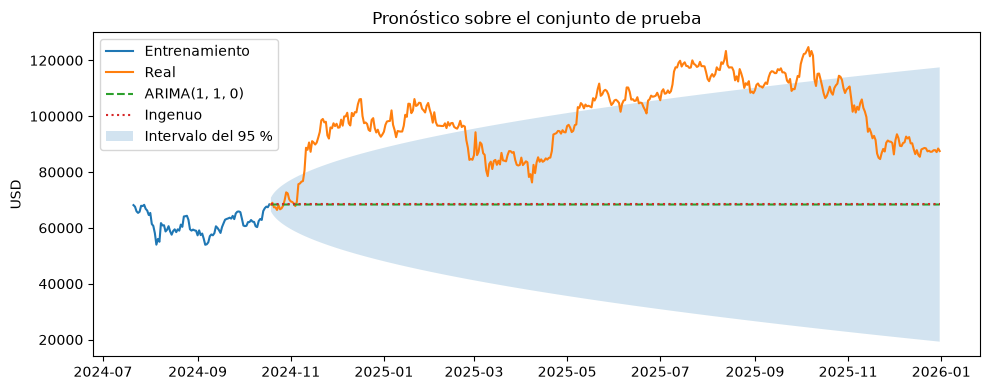

In [14]:
pronostico = modelo.get_forecast(steps=len(test))
intervalo = pronostico.conf_int(alpha=alpha)
prediccion = pronostico.predicted_mean

evaluacion = pd.DataFrame({'Real': test, 'Pronóstico': prediccion,
                           'Ingenuo': train.iloc[-1],
                           'Inferior 95%': intervalo.iloc[:, 0],
                           'Superior 95%': intervalo.iloc[:, 1]})
display(evaluacion.head())
display(evaluacion.tail())

plt.plot(train.tail(90), label='Entrenamiento')
plt.plot(test, label='Real')
plt.plot(prediccion, label=nombre, linestyle='--')
plt.plot(test.index, evaluacion['Ingenuo'], label='Ingenuo', linestyle=':')
plt.fill_between(test.index, intervalo.iloc[:, 0], intervalo.iloc[:, 1],
                 alpha=0.2, label='Intervalo del 95 %')
plt.title('Pronóstico sobre el conjunto de prueba')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()

### 7.2. Errores del pronóstico

MSE, RMSE, MAE y MAPE: cuanto menores, mejor. RMSE y MAE se expresan en USD, MSE en USD² y MAPE en porcentaje. Las métricas del bloque completo se complementan con sus primeros 30 días, un horizonte más corto.

In [15]:
def metricas(real, estimado):
    error = real - estimado
    mse = np.mean(error ** 2)
    return {'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': np.mean(np.abs(error)),
            'MAPE (%)': np.mean(np.abs(error / real)) * 100}

metricas_test = pd.DataFrame({
    nombre: metricas(test, evaluacion['Pronóstico']),
    'Ingenuo': metricas(test, evaluacion['Ingenuo'])
}).T
print('Todo el conjunto de prueba:')
display(metricas_test.round(2))
print('Primeros 30 días de prueba:')
display(pd.DataFrame({
    nombre: metricas(test.iloc[:30], evaluacion['Pronóstico'].iloc[:30]),
    'Ingenuo': metricas(test.iloc[:30], evaluacion['Ingenuo'].iloc[:30])
}).T.round(2))

Todo el conjunto de prueba:


,MSE,RMSE,MAE,MAPE (%)
"ARIMA(1, 1, 0)",1.128829e+09,33598.05,31063.88,30.00
Ingenuo,1.125821e+09,33553.26,31017.37,29.95


Primeros 30 días de prueba:


,MSE,RMSE,MAE,MAPE (%)
"ARIMA(1, 1, 0)",1.188108e+08,10900.03,7161.09,8.51
Ingenuo,1.181717e+08,10870.68,7141.77,8.49


### 7.3. Reajuste y pronóstico de 30 días posteriores al dataset

Se conserva el orden elegido y se reestiman los parámetros con toda la serie. El horizonte empieza después de la última fecha descargada; este pronóstico no es una evaluación con datos observados.

,Pronóstico,Inferior 95%,Superior 95%
2026-01-01,87549.95,84633.93,90465.97
2026-01-02,87548.11,83515.21,91581.01
2026-01-03,87548.19,82643.32,92453.07
2026-01-04,87548.19,81904.62,93191.75
2026-01-05,87548.19,81252.00,93844.37
2026-01-06,87548.19,80660.95,94435.43
2026-01-07,87548.19,80116.76,94979.62
2026-01-08,87548.19,79609.78,95486.60
2026-01-09,87548.19,79133.30,95963.08
2026-01-10,87548.19,78682.38,96414.00


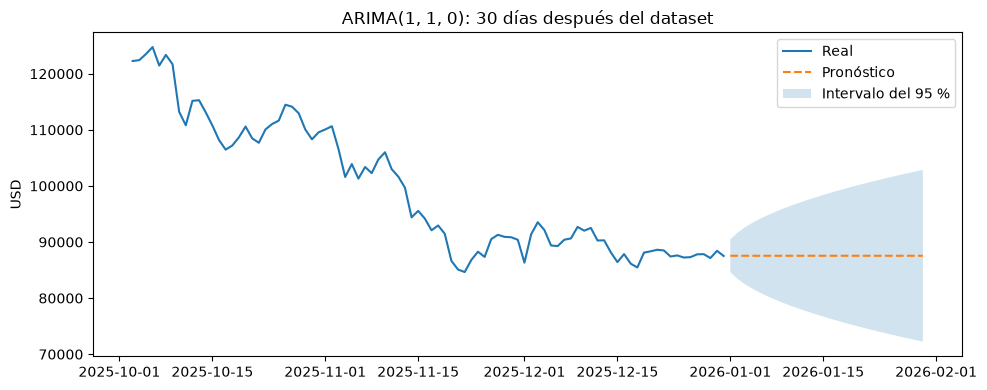

In [16]:
modelo_final = ARIMA(serie, order=orden_elegido, trend=trend).fit(
    method_kwargs={'maxiter': 200})
if not modelo_final.mle_retvals.get('converged', False):
    raise ValueError('El reajuste final no convergió. Revisar antes de pronosticar.')

futuro = modelo_final.get_forecast(steps=30)
intervalo_futuro = futuro.conf_int(alpha=alpha)
tabla_futuro = pd.DataFrame({'Pronóstico': futuro.predicted_mean,
                             'Inferior 95%': intervalo_futuro.iloc[:, 0],
                             'Superior 95%': intervalo_futuro.iloc[:, 1]})
display(tabla_futuro.round(2))

plt.plot(serie.tail(90), label='Real')
plt.plot(tabla_futuro['Pronóstico'], label='Pronóstico', linestyle='--')
plt.fill_between(tabla_futuro.index, tabla_futuro['Inferior 95%'],
                 tabla_futuro['Superior 95%'], alpha=0.2, label='Intervalo del 95 %')
plt.title(f'ARIMA{orden_elegido}: 30 días después del dataset')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusiones

In [17]:
print(f'1. Se analizaron {len(serie)} precios diarios de {simbolo}.')
print(f'2. Se seleccionó d={d}, el menor orden compatible con ADF.')
print(f'3. El modelo elegido entre los candidatos fue {f'ARIMA{orden_elegido}'}.')
rmse_modelo = metricas_test.loc[f'ARIMA{orden_elegido}', 'RMSE']
rmse_ingenuo = metricas_test.loc['Ingenuo', 'RMSE']
print(f'4. RMSE de prueba: {rmse_modelo:.2f} USD; referencia ingenua: {rmse_ingenuo:.2f} USD.')
if np.isclose(rmse_modelo, rmse_ingenuo):
    print('   El resultado es equivalente al pronóstico ingenuo.')
elif rmse_modelo < rmse_ingenuo:
    print('   El modelo mejora la referencia en este periodo.')
else:
    print('   El modelo no mejora la referencia en este periodo.')
if (lb['lb_pvalue'] < alpha).any():
    print('5. Queda autocorrelación residual: revisar la identificación del modelo.')
else:
    print('5. No se detecta autocorrelación residual en los rezagos evaluados.')
if arch[1] < alpha or jb[1] < alpha:
    print('6. Hay limitaciones de varianza o normalidad: los intervalos son aproximados.')
    print('   Diferenciar no garantiza varianza constante; explorar logaritmos o ARCH/GARCH como extensión.')
else:
    print('6. Las pruebas no detectaron efectos ARCH ni desviaciones de normalidad al 5 %.')

1. Se analizaron 2192 precios diarios de BTC-USD.
2. Se seleccionó d=1, el menor orden compatible con ADF.
3. El modelo elegido entre los candidatos fue ARIMA(1, 1, 0).
4. RMSE de prueba: 33598.05 USD; referencia ingenua: 33553.26 USD.
   El modelo no mejora la referencia en este periodo.
5. No se detecta autocorrelación residual en los rezagos evaluados.
6. Hay limitaciones de varianza o normalidad: los intervalos son aproximados.
   Diferenciar no garantiza varianza constante; explorar logaritmos o ARCH/GARCH como extensión.


### Referencias

Material de clase: `01. Introducción a la programación para Series de Tiempo.ipynb`, `02. Series estacionarias y no estacionarias.ipynb`, `04. Modelos ARMA.ipynb` y los tres PDF de `TeoriayScrips`.

Consulta técnica: [yfinance](https://ranaroussi.github.io/yfinance/reference/yfinance.stock.html), [ARIMA](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html), [KPSS](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.kpss.html) y [Ljung–Box](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.acorr_ljungbox.html).

## 10. Opción 2: modelar rendimientos logarítmicos

Los precios suelen producir pronósticos planos. Como alternativa, se modela el rendimiento logarítmico diario:

`r(t) = log(Precio(t) / Precio(t−1))`

Después se acumulan los rendimientos pronosticados para volver a la escala del precio.

Rendimientos: 2191 observaciones
Rendimiento logarítmico: ADF=-13.6978; p-valor=0.0000; estacionaria


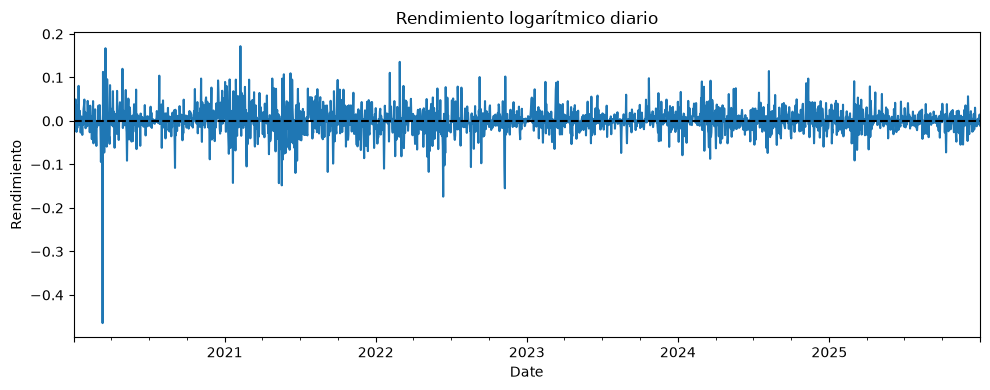

In [18]:
# Crear rendimientos a partir del precio original
precio = serie.copy()
rendimiento = np.log(precio / precio.shift(1)).dropna()

corte_r = int(len(rendimiento) * 0.8)
train_r = rendimiento.iloc[:corte_r]
test_r = rendimiento.iloc[corte_r:]
precio_test = precio.loc[test_r.index]
precio_inicial = precio.loc[train_r.index[-1]]

print(f'Rendimientos: {len(rendimiento)} observaciones')
prueba_adf(train_r, 'Rendimiento logarítmico')
rendimiento.plot(title='Rendimiento logarítmico diario', ylabel='Rendimiento')
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout(); plt.show()

### Selección del modelo para rendimientos

Los rendimientos ya son estacionarios en niveles, por lo que se usa `d=0`. Se comparan modelos AR, MA y ARMA pequeños mediante AIC.

In [19]:
modelos_r, resultados_r = {}, []
for p in range(3):
    for q in range(3):
        orden_r = (p, 0, q)
        try:
            ajuste_r = ARIMA(train_r, order=orden_r, trend='c').fit()
            if np.isfinite(ajuste_r.aic):
                modelos_r[orden_r] = ajuste_r
                resultados_r.append({'Orden': orden_r, 'AIC': ajuste_r.aic, 'BIC': ajuste_r.bic})
        except (ValueError, np.linalg.LinAlgError):
            pass
comparacion_r = pd.DataFrame(resultados_r).sort_values('AIC').reset_index(drop=True)
display(comparacion_r)
orden_r = tuple(comparacion_r.loc[0, 'Orden'])
modelo_r = modelos_r[orden_r]
print('Modelo de rendimientos elegido: ARIMA', orden_r)

,Orden,AIC,BIC
0,"(1, 0, 1)",-6846.016601,-6824.142548
1,"(2, 0, 0)",-6844.137931,-6822.263878
2,"(2, 0, 2)",-6843.886976,-6811.075896
3,"(0, 0, 2)",-6843.469055,-6821.595002
4,"(2, 0, 1)",-6842.812135,-6815.469568
5,"(1, 0, 0)",-6842.094814,-6825.689274
6,"(1, 0, 2)",-6842.068643,-6814.726077
7,"(0, 0, 1)",-6841.550121,-6825.144581
8,"(0, 0, 0)",-6838.052147,-6827.115120


Modelo de rendimientos elegido: ARIMA (1, 0, 1)


In [20]:
# Diagnóstico sencillo de los residuos del modelo de rendimientos
resid_r = modelo_r.resid.dropna()
lb_r = acorr_ljungbox(resid_r, lags=[10], return_df=True)
print('p-valor Ljung–Box:', round(lb_r['lb_pvalue'].iloc[0], 4))


p-valor Ljung–Box: 0.1141


### Pronóstico de rendimientos y reconstrucción del precio

,Precio real,Pronóstico por rendimientos,Ingenuo
2024-10-19,68362.734375,68412.973944,68418.789062
2024-10-20,69001.703125,68560.678498,68418.789062
2024-10-21,67367.851562,68610.010735,68418.789062
2024-10-22,67361.406250,68722.690096,68418.789062
2024-10-23,66432.195312,68794.884663,68418.789062


,MSE,RMSE,MAE,MAPE (%)
Rendimientos,2.875719e+08,16957.94,14377.81,14.42
Ingenuo,1.125821e+09,33553.26,31017.37,29.95


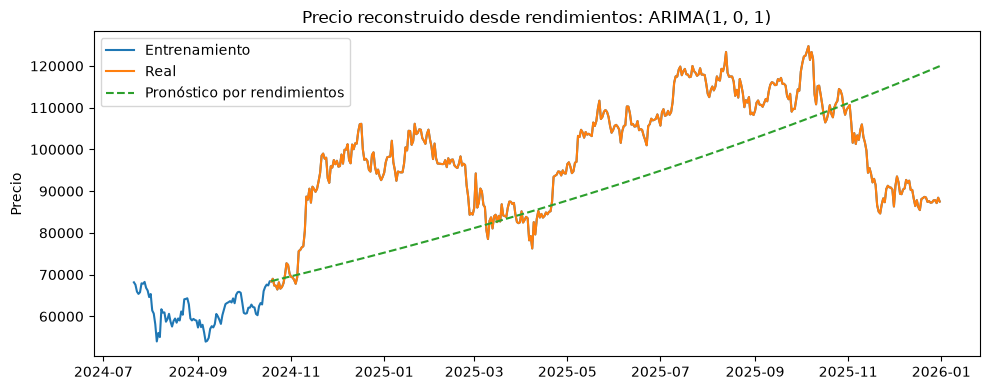

In [21]:
pron_r = modelo_r.get_forecast(steps=len(test_r)).predicted_mean
precio_pron_r = precio_inicial * np.exp(pron_r.cumsum())

# Referencia ingenua: repetir el último precio de entrenamiento
ingenuo_r = pd.Series(precio_inicial, index=precio_test.index)

tabla_r = pd.DataFrame({'Precio real': precio_test, 'Pronóstico por rendimientos': precio_pron_r,
                        'Ingenuo': ingenuo_r})
display(tabla_r.head())
display(pd.DataFrame({'Rendimientos': metricas(precio_test, precio_pron_r),
                     'Ingenuo': metricas(precio_test, ingenuo_r)}).T.round(2))

plt.plot(precio.loc[train_r.index[-90]:], label='Entrenamiento')
plt.plot(precio_test, label='Real')
plt.plot(precio_pron_r, '--', label='Pronóstico por rendimientos')
plt.title(f'Precio reconstruido desde rendimientos: ARIMA{orden_r}')
plt.ylabel('Precio')
plt.legend(); plt.tight_layout(); plt.show()

La opción 2 evita predecir directamente el nivel del precio. El precio final se obtiene acumulando los rendimientos esperados; por ello también puede acercarse a una línea plana cuando el rendimiento esperado es cercano a cero.